In [13]:
# ================= IMPORTS =================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import DenseNet201

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

2026-05-06 14:41:32.193549: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778078492.690736      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778078492.818715      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778078493.972225      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778078493.972267      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778078493.972269      57 computation_placer.cc:177] computation placer alr

In [14]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [15]:
import os
print(os.listdir('/kaggle/input/datasets'))

['thomasdubail']


In [16]:
print(os.listdir('/kaggle/input/datasets/thomasdubail'))

['brain-tumors-256x256']


In [17]:
print(os.listdir('/kaggle/input/datasets/thomasdubail/brain-tumors-256x256'))

['Data']


In [18]:
DATASET_PATH = "/kaggle/input/datasets/thomasdubail/brain-tumors-256x256/Data"

IMG_SIZE = 224
BATCH_SIZE = 32

In [19]:
# ================= DATA GENERATOR =================
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
val_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# ================= LOAD DATA =================
train_data = train_gen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = val_gen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("\n✅ Classes:")
print(val_data.class_indices)


Found 2479 images belonging to 4 classes.
Found 617 images belonging to 4 classes.

✅ Classes:
{'glioma_tumor': 0, 'meningioma_tumor': 1, 'normal': 2, 'pituitary_tumor': 3}


I0000 00:00:1778078593.590154      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778078593.596016      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🔥 NORMAL TRAINING STARTED...



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1778078621.520700     166 service.cc:152] XLA service 0x79e00c42ad10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778078621.520747     166 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778078621.520753     166 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778078626.998529     166 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/78 ━━━━━━━━━━━━━━━━━━━━ 1:02:27 49s/step - accuracy: 0.2188 - loss: 1.9809

I0000 00:00:1778078649.702504     166 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


78/78 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.4527 - loss: 1.3195 - val_accuracy: 0.6677 - val_loss: 0.8640 - learning_rate: 1.0000e-04
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 33s 418ms/step - accuracy: 0.7107 - loss: 0.7642 - val_accuracy: 0.7666 - val_loss: 0.6539 - learning_rate: 1.0000e-04
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 32s 404ms/step - accuracy: 0.7727 - loss: 0.6062 - val_accuracy: 0.7942 - val_loss: 0.5522 - learning_rate: 1.0000e-04
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 33s 421ms/step - accuracy: 0.8011 - loss: 0.5450 - val_accuracy: 0.8104 - val_loss: 0.5132 - learning_rate: 1.0000e-04
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 32s 410ms/step - accuracy: 0.8234 - loss: 0.4737 - val_accuracy: 0.8169 - val_loss: 0.4900 - learning_rate: 1.0000e-04
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 33s 416ms/step - accuracy: 0.8320 - loss: 0.4375 - val_accuracy: 0.8217 - val_loss: 0.4681 - learning_rate: 1.0000e-04
Epoch 7/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 32s 406ms/step - accuracy: 0.8458

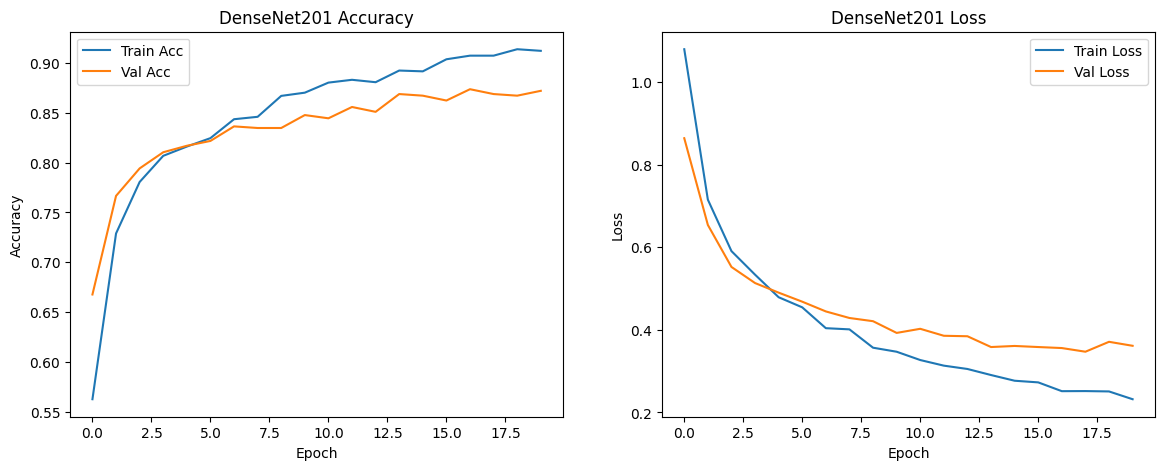


🔥 GENERATING CONFUSION MATRIX...

20/20 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step 


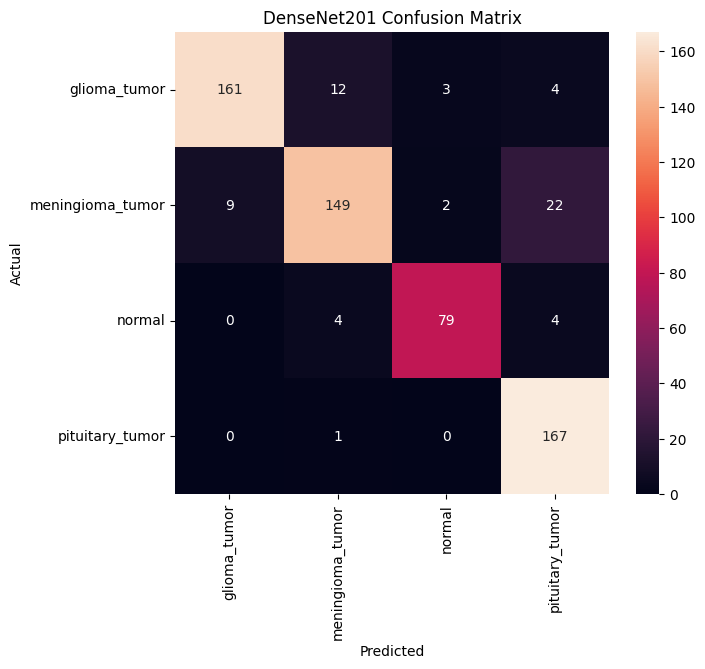


🔥 GENERATING ROC CURVE...



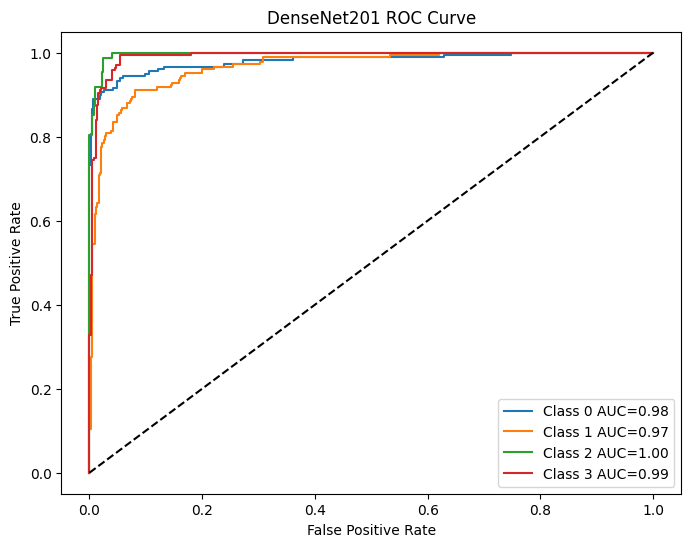


🔥 GENERATING SAMPLE RESULTS...



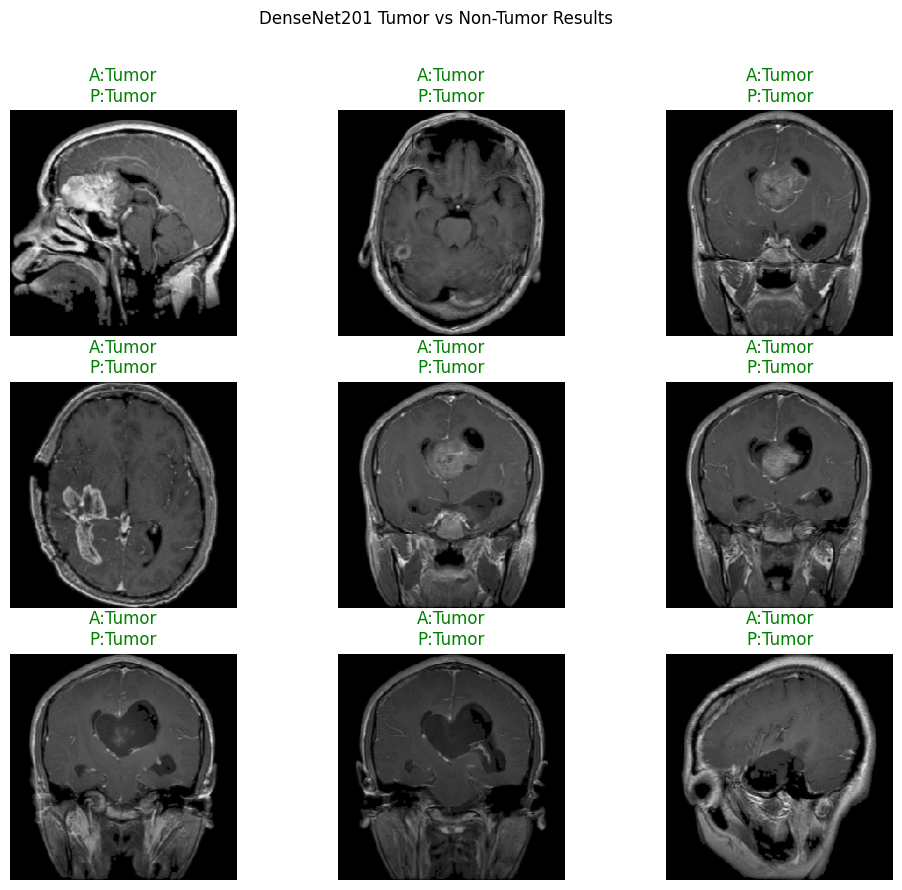


🔥 CLASSIFICATION REPORT

                  precision    recall  f1-score   support

    glioma_tumor       0.95      0.89      0.92       180
meningioma_tumor       0.90      0.82      0.86       182
          normal       0.94      0.91      0.92        87
 pituitary_tumor       0.85      0.99      0.92       168

        accuracy                           0.90       617
       macro avg       0.91      0.90      0.90       617
    weighted avg       0.90      0.90      0.90       617


✅ MODEL SAVED SUCCESSFULLY


In [20]:
# ================= MODEL =================
base = DenseNet201(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

out = Dense(4, activation='softmax')(x)

model = Model(inputs=base.input, outputs=out)

# ================= COMPILE =================
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ================= CALLBACK =================
lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.3,
    verbose=1
)

# =========================================================
# 🔵 NORMAL TRAINING (STRICT 20 EPOCHS)
# =========================================================

print("\n🔥 NORMAL TRAINING STARTED...\n")

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[lr_reduce]
)

# ================= NORMAL ACCURACY =================
loss, acc = model.evaluate(val_data)

print("\n✅ DenseNet201 Normal Accuracy:", acc * 100)

# =========================================================
# 🔥 FINE-TUNING (STRICT 20 EPOCHS)
# =========================================================

print("\n🔥 FINE-TUNING STARTED...\n")

# Unfreeze last 120 layers
for layer in base.layers[-120:]:
    layer.trainable = True

# Recompile
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[lr_reduce]
)

# ================= FINAL ACCURACY =================
loss, final_acc = model.evaluate(val_data)

print("\n🔥 DenseNet201 Final Accuracy:", final_acc * 100)

# =========================================================
# 📊 ACCURACY & LOSS CURVES
# =========================================================

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')

plt.title("DenseNet201 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.title("DenseNet201 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# =========================================================
# 📊 CONFUSION MATRIX
# =========================================================

print("\n🔥 GENERATING CONFUSION MATRIX...\n")

val_data.reset()

y_prob = model.predict(val_data)
y_pred = np.argmax(y_prob, axis=1)

y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=val_data.class_indices.keys(),
    yticklabels=val_data.class_indices.keys()
)

plt.title("DenseNet201 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# =========================================================
# 📊 ROC CURVE
# =========================================================

print("\n🔥 GENERATING ROC CURVE...\n")

y_true_bin = label_binarize(y_true, classes=[0,1,2,3])

plt.figure(figsize=(8,6))

for i in range(4):

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {i} AUC={roc_auc:.2f}')

plt.plot([0,1],[0,1],'k--')

plt.title("DenseNet201 ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

# =========================================================
# 📸 TUMOR vs NON-TUMOR RESULTS
# =========================================================

print("\n🔥 GENERATING SAMPLE RESULTS...\n")

class_names = list(val_data.class_indices.keys())

def tumor_label(label):

    if label == "normal":
        return "Non-Tumor"
    else:
        return "Tumor"

val_data.reset()

x_batch, y_batch = next(val_data)

plt.figure(figsize=(12,10))

for i in range(9):

    img = x_batch[i]

    # Actual
    actual_class = class_names[np.argmax(y_batch[i])]
    actual = tumor_label(actual_class)

    # Prediction
    pred = np.argmax(
        model.predict(
            img.reshape(1,224,224,3),
            verbose=0
        )
    )

    pred_class = class_names[pred]
    predicted = tumor_label(pred_class)

    color = "green" if actual == predicted else "red"

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(
        f"A:{actual}\nP:{predicted}",
        color=color
    )

    plt.axis('off')

plt.suptitle("DenseNet201 Tumor vs Non-Tumor Results")

plt.show()

# =========================================================
# 📄 CLASSIFICATION REPORT
# =========================================================

print("\n🔥 CLASSIFICATION REPORT\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

# =========================================================
# ✅ SAVE MODEL
# =========================================================

model.save("DenseNet201_BrainTumor.h5")

print("\n✅ MODEL SAVED SUCCESSFULLY")

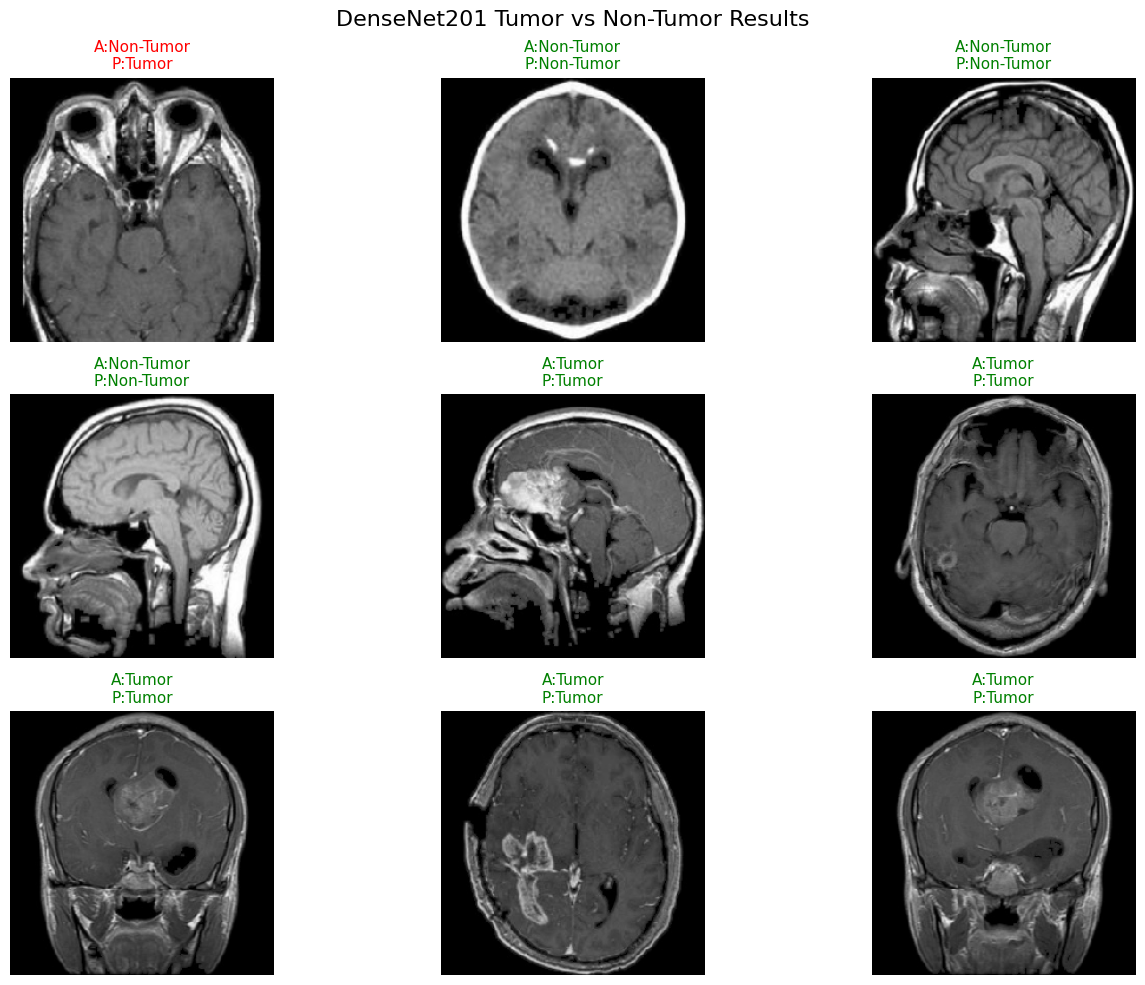

In [21]:
# =========================================================
# 📸 DENSENET201 - TUMOR vs NON-TUMOR SAMPLE RESULTS
# (3-4 Non-Tumor + Remaining Tumor Images)
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

# Reset generator
val_data.reset()

# Class names
class_names = list(val_data.class_indices.keys())

# Function
def tumor_label(label):

    if label == "normal":
        return "Non-Tumor"
    else:
        return "Tumor"

# =========================================================
# COLLECT IMAGES
# =========================================================

tumor_imgs = []
non_tumor_imgs = []

# Loop through validation data
for batch_x, batch_y in val_data:

    for i in range(len(batch_x)):

        img = batch_x[i]

        actual_class = class_names[np.argmax(batch_y[i])]

        # Prediction
        pred = np.argmax(
            model.predict(
                img.reshape(1,224,224,3),
                verbose=0
            )
        )

        pred_class = class_names[pred]

        actual = tumor_label(actual_class)
        predicted = tumor_label(pred_class)

        result = (
            img,
            actual,
            predicted
        )

        # Store separately
        if actual == "Non-Tumor":

            if len(non_tumor_imgs) < 4:
                non_tumor_imgs.append(result)

        else:

            if len(tumor_imgs) < 5:
                tumor_imgs.append(result)

    # Stop when enough images collected
    if len(non_tumor_imgs) >= 4 and len(tumor_imgs) >= 5:
        break

# Combine images
final_images = non_tumor_imgs + tumor_imgs

# =========================================================
# DISPLAY RESULTS
# =========================================================

plt.figure(figsize=(14,10))

for i, (img, actual, predicted) in enumerate(final_images):

    color = "green" if actual == predicted else "red"

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(
        f"A:{actual}\nP:{predicted}",
        color=color,
        fontsize=11
    )

    plt.axis('off')

plt.suptitle(
    "DenseNet201 Tumor vs Non-Tumor Results",
    fontsize=16
)

plt.tight_layout()

plt.show()